# DES figures

Fig. 2b, 2d and Supplementary Fig. S3c, S4 and S5b. Each panel is written to `figures/` (PDF) and the values it plots to `data/` (CSV; for S4c, the size, median and quartiles of each half-violin).

- **Fig. 2b, 2d, S3c, S5b**: the per-perturbation tables of the DES scorer, `DES_PER_PERT` and `DES_THRESHOLD_PER_PERT` (`5_response_hierarchy/des_scoring/README.md`), averaged over unique held-out perturbations below.
- **Fig. S4a-c**: the per-dataset tables of `5_response_hierarchy/compute_breadth_stratified_des.py` (`RESPONSE_BREADTH`), pooled and matched in the S4 section.

By default the notebook plots the frozen paper summaries of these tables (`results_reference/`: `DES_SOURCES`, `09_des_threshold/paper_figure_S5b/source_data/` and `paper_figure_S4/source_data/` of `RESPONSE_BREADTH`). Set `USE_REFERENCE=0` (or `USE_REFERENCE = False` below) to recompute them from the DES scorer tables and, for S4, from `results/` after `bash 5_response_hierarchy/run.sh`.

In [1]:
%matplotlib inline
import math
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # the repository root, for utils
from utils.paths import (
    DATASET_ORDER,
    DES_PER_PERT,
    DES_SOURCES,
    DES_THRESHOLD_PER_PERT,
    REFERENCE_RESULTS,
    REPO_ROOT,
    RESPONSE_BREADTH,
    paper_name,
    reference,
    slug,
)
from utils.plotting import MM, METHOD_LABELS, method_palette, panel_style, save_panel, use_style

USE_REFERENCE = os.environ.get("USE_REFERENCE", "1") != "0"

# The frozen paper summaries, plotted when USE_REFERENCE is on.
FROZEN_DES = reference(DES_SOURCES) / "des_by_unique_perturbation.csv.gz"
FROZEN_CUTOFFS = REFERENCE_RESULTS / "09_des_threshold/paper_figure_S5b/source_data/des_threshold_dataset_summary.csv"
FROZEN_S4 = reference(RESPONSE_BREADTH) / "paper_figure_S4" / "source_data"

FIGURES = REPO_ROOT / "5_response_hierarchy" / "figures"
DATA = REPO_ROOT / "5_response_hierarchy" / "data"
FIGURES.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

# the 11 biological datasets
DES_DATASETS = [dataset for dataset in DATASET_ORDER if dataset != "Feng-GW"]


def two_lines(name):
    """A paper name broken after its last hyphen, for narrow panel titles."""
    head, _, tail = name.rpartition("-")
    return f"{head}-\n{tail}"

## DES tables — Fig. 2b, 2d, S3c, S5b

DES is averaged within each dataset, space, method and unique held-out perturbation (not over folds first). The spaces become the conditions `original` (before_detrend, total-effect truth) and `conjunction` (after_detrend, residual-effect truth), and each perturbation gets the count group of its original non-target discoveries k (0, 1-4, 5-9, 10-19, >=20). The cutoff summary keeps the perturbations with k >= 20, averages DES within perturbation and then over perturbations at each residual-effect cutoff, and sets relative DES = (method − random) / (best method − random) per dataset and cutoff. Only the 11 biological datasets are kept.

In [2]:
def count_group(values):
    groups = pd.Series(index=values.index, dtype="object")
    groups.loc[values.eq(0)] = "0"
    groups.loc[values.between(1, 4)] = "1-4"
    groups.loc[values.between(5, 9)] = "5-9"
    groups.loc[values.between(10, 19)] = "10-19"
    groups.loc[values.ge(20)] = ">=20"
    return groups


def original_discoveries(scores):
    """k of the total-effect truth of each dataset and perturbation."""
    original = scores.loc[scores["space"].eq("before_detrend")]
    return (
        original.groupby(["dataset", "perturbation"], as_index=False)["k"]
        .first()
        .rename(columns={"k": "original_rejections"})
    )


def unique_perturbation_des(scores, counts):
    """DES of each dataset, condition, method and unique held-out perturbation (2b, S3c)."""
    selected = scores.loc[scores["dataset"].isin(DES_DATASETS) & scores["des"].notna()]
    table = (
        selected.groupby(["dataset", "space", "method", "perturbation"], as_index=False, sort=False)
        .agg(DES=("des", "mean"))
        .merge(counts, on=["dataset", "perturbation"], how="left")
    )
    table["condition"] = table["space"].map({"before_detrend": "original", "after_detrend": "conjunction"})
    table["original_rejection_group"] = count_group(table["original_rejections"])
    return table


def cutoff_summary(threshold, counts):
    """Mean and relative DES of each dataset, residual-effect cutoff and method (2d, S5b)."""
    eligible = counts.loc[counts["dataset"].isin(DES_DATASETS) & counts["original_rejections"].ge(20)]
    selected = threshold.merge(eligible, on=["dataset", "perturbation"], how="inner")
    selected = selected.loc[selected["des"].notna() & selected["k"].gt(0)]
    per_perturbation = (
        selected.groupby(["dataset", "threshold", "method", "perturbation"], as_index=False, sort=False)
        .agg(DES=("des", "mean"), thresholded_discoveries=("k", "first"))
    )
    summary = per_perturbation.groupby(["dataset", "threshold", "method"], as_index=False).agg(
        mean_DES_over_unique_perturbations=("DES", "mean"),
        n_unique_perturbations=("perturbation", "nunique"),
        mean_thresholded_discoveries_per_perturbation=("thresholded_discoveries", "mean"),
        median_thresholded_discoveries_per_perturbation=("thresholded_discoveries", "median"),
    )

    wide = summary.pivot(index=["dataset", "threshold"], columns="method", values="mean_DES_over_unique_perturbations")
    methods = [column for column in wide.columns if column != "random"]
    normalizers = pd.concat(
        [wide["random"].rename("mean_random_DES"), wide[methods].max(axis=1).rename("best_available_mean_DES")],
        axis=1,
    ).reset_index()
    summary = summary.merge(normalizers, on=["dataset", "threshold"], how="left")
    summary["DES_above_random"] = summary["mean_DES_over_unique_perturbations"] - summary["mean_random_DES"]
    summary["normalized_DES"] = summary["DES_above_random"] / (
        summary["best_available_mean_DES"] - summary["mean_random_DES"]
    )
    summary["display_dataset"] = summary["dataset"].map(paper_name)
    summary["display_method"] = summary["method"].map(METHOD_LABELS)
    summary["aggregation_unit"] = "unique held-out perturbation"
    return summary[[
        "dataset", "display_dataset", "threshold", "method", "display_method",
        "mean_DES_over_unique_perturbations", "mean_random_DES", "DES_above_random", "best_available_mean_DES",
        "normalized_DES", "n_unique_perturbations", "mean_thresholded_discoveries_per_perturbation",
        "median_thresholded_discoveries_per_perturbation", "aggregation_unit",
    ]].sort_values(["dataset", "threshold", "method"])


if USE_REFERENCE:
    des_by_perturbation = pd.read_csv(FROZEN_DES)
    des_cutoffs = pd.read_csv(FROZEN_CUTOFFS)
else:
    des_scores = pd.read_csv(DES_PER_PERT)
    original_counts = original_discoveries(des_scores)
    des_by_perturbation = unique_perturbation_des(des_scores, original_counts)
    des_cutoffs = cutoff_summary(pd.read_csv(DES_THRESHOLD_PER_PERT), original_counts)

## Fig. 2b — DES for total-effect discoveries

Mean paired DES minus random over the unique held-out perturbations with at least 20 original non-target discoveries (CV folds are not summary units); train mean is not drawn. Datasets are ordered by the DE-frequency gain minus the best alternative gain. 75 × 133.65 mm; the same code draws S3c.

In [3]:
# Train mean is deliberately excluded. DE frequency is the rejfreq method.
BAR_METHODS = method_palette(["rejfreq", "presage", "weighted", "linear_otherds", "linear_train", "gears", "scGPT-ft"])
BAR_RC = {"font.size": 7.4, "axes.linewidth": 0.65}


def des_above_random(raw, condition):
    """Bars of one DES condition in display order, and the dataset ranking behind that order."""
    method_meta = {
        key: {"display_method": label, "color": color, "method_order": order}
        for order, (key, label, color) in enumerate(BAR_METHODS)
    }
    selected = raw.loc[raw["condition"].eq(condition) & raw["original_rejection_group"].eq(">=20")].copy()
    rows = []
    for dataset, subset in selected.groupby("dataset", sort=False):
        wide = subset.pivot(index="perturbation", columns="method", values="DES")
        chance = wide["random"]
        for method, method_info in method_meta.items():
            if method not in wide:
                continue
            paired = (wide[method] - chance).dropna()
            if paired.empty:
                continue
            rows.append({
                "dataset": dataset,
                "display_dataset": paper_name(dataset),
                "condition": condition,
                "method": method,
                **method_info,
                "n_perturbations": len(paired),
                "mean_des_minus_random": float(paired.mean()),
                "sd_des_minus_random": float(paired.std(ddof=1)),
                "mean_random_des": float(chance.reindex(paired.index).mean()),
            })
    bars = pd.DataFrame(rows)

    ranking = bars.loc[
        bars["method"] == "rejfreq", ["dataset", "display_dataset", "mean_des_minus_random"]
    ].rename(columns={"mean_des_minus_random": "de_frequency_gain"})
    alternatives = bars.loc[bars["method"] != "rejfreq"]
    best = alternatives.loc[
        alternatives.groupby("dataset")["mean_des_minus_random"].idxmax(),
        ["dataset", "display_method", "mean_des_minus_random"],
    ].rename(columns={
        "display_method": "best_alternative_method",
        "mean_des_minus_random": "best_alternative_gain",
    })
    ranking = ranking.merge(best, on="dataset", how="left")
    ranking["de_frequency_advantage"] = ranking["de_frequency_gain"] - ranking["best_alternative_gain"]
    ranking = ranking.sort_values(
        ["de_frequency_advantage", "de_frequency_gain"], ascending=[False, False]
    ).reset_index(drop=True)
    ranking.insert(0, "display_rank", np.arange(1, len(ranking) + 1))

    bars["display_order"] = bars["dataset"].map({dataset: rank for rank, dataset in enumerate(ranking["dataset"])})
    return bars.sort_values(["display_order", "method_order"]), ranking


def draw_des_bars(bars, ranking, title):
    figure, axis = plt.subplots(figsize=(75.0 * MM, 133.65 * MM))
    figure.subplots_adjust(left=0.490, right=0.970, bottom=0.180, top=0.925)

    centers = {dataset: float(index) for index, dataset in enumerate(ranking["dataset"])}
    method_offsets = {
        key: (index - (len(BAR_METHODS) - 1) / 2.0) * 0.073 for index, (key, _, _) in enumerate(BAR_METHODS)
    }
    for _, row in bars.iterrows():
        axis.barh(
            centers[row["dataset"]] + method_offsets[row["method"]], row["mean_des_minus_random"],
            height=0.043, color=row["color"], edgecolor="none", zorder=3,
        )

    # Three percent headroom, rounded up to the next 0.01, keeps the axis tight.
    x_max = round(math.ceil((float(bars["mean_des_minus_random"].max()) * 1.03) / 0.01) * 0.01, 2)
    axis.set_yticks(list(centers.values()), ranking["display_dataset"].tolist(), fontsize=8.0)
    axis.set_ylim(centers[ranking["dataset"].iloc[-1]] + 0.48, -0.48)
    axis.set_xlim(0.0, x_max)
    ticks = np.arange(0.0, x_max + 1e-12, 0.10)
    axis.set_xticks(ticks)
    axis.set_xticklabels(["0" if np.isclose(value, 0) else f"{value:.2f}" for value in ticks], fontsize=7.9)
    axis.set_xlabel("DES above random", fontsize=8.3, labelpad=1)
    axis.tick_params(axis="y", length=0, pad=2)
    axis.tick_params(axis="x", width=0.6, length=3, color="#4A4A4A")
    axis.grid(axis="x", color="#E2E2E2", linewidth=0.55, zorder=0)
    axis.grid(axis="y", visible=False)
    axis.spines["left"].set_visible(False)
    axis.spines["bottom"].set_color("#4A4A4A")
    figure.suptitle(title, x=0.5, y=0.992, ha="center", va="top", fontsize=9.2, fontweight="bold", linespacing=1.05)

    handles = [Patch(facecolor=color, edgecolor="none", label=label) for _, label, color in BAR_METHODS]
    # Matplotlib fills multi-column legends down columns; reorder so that the
    # legend reads left to right across each row.
    ncols = 2
    handles = [handles[index] for column in range(ncols) for index in range(column, len(handles), ncols)]
    figure.legend(
        handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.010), ncol=ncols, fontsize=6.8,
        handlelength=1.00, handleheight=0.70, handletextpad=0.42, columnspacing=0.80, labelspacing=0.48,
        borderaxespad=0,
    )
    return figure

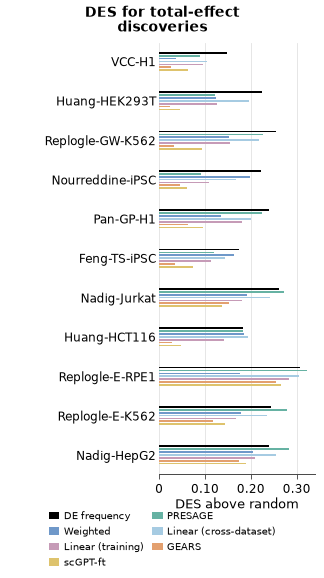

In [4]:
fig2b_bars, fig2b_ranking = des_above_random(des_by_perturbation, "original")

with mpl.rc_context():  # restores the notebook style after the panel
    use_style(BAR_RC, open_axes=True)
    figure = draw_des_bars(fig2b_bars, fig2b_ranking, "DES for total-effect\ndiscoveries")
    save_panel(figure, FIGURES / "DES_total_effect_discoveries.pdf")

## Fig. 2d — relative DES across residual-effect cutoffs

Relative DES (random = 0, best method = 1 per dataset and cutoff) of five methods in VCC-H1, Replogle-E-RPE1 and Feng-TS-iPSC. 91.5 × 45 mm.

In [5]:
FIG2D_DATASETS = ["VCC", "Replogle-E-rpe1", "Feng-ts"]
# panel titles: the paper names, on two lines except the short VCC-H1
FIG2D_TITLES = [paper_name(d) if d == "VCC" else two_lines(paper_name(d)) for d in FIG2D_DATASETS]
FIG2D_METHODS = [
    ("rejfreq", "DE frequency", "#222222", 1.55, "o"),
    ("weighted", "Weighted", "#4C78A8", 1.12, None),
    ("presage", "PRESAGE", "#2A9D8F", 1.12, None),
    ("linear_otherds", "Linear (other datasets)", "#72B7D2", 1.12, None),
    ("linear_train", "Linear (training)", "#B07AA1", 1.12, None),
]
FIG2D_RC = {
    "font.size": 7.0, "axes.linewidth": 0.60, "xtick.major.width": 0.60, "ytick.major.width": 0.60,
    "xtick.major.size": 2.3, "ytick.major.size": 2.3,
}


def select_cutoff_rows(datasets, methods):
    """Plotted rows (2d, S5b), in panel, method and cutoff order."""
    method_order = [method for method, *_ in methods]
    selected = des_cutoffs.loc[
        des_cutoffs["dataset"].isin(datasets) & des_cutoffs["method"].isin(method_order)
    ].copy()
    selected["dataset"] = pd.Categorical(selected["dataset"], datasets, ordered=True)
    selected["method"] = pd.Categorical(selected["method"], method_order, ordered=True)
    return selected.sort_values(["dataset", "method", "threshold"]).reset_index(drop=True)


def draw_fig2d(selected):
    fig, axes = plt.subplots(1, 3, figsize=(91.5 * MM, 45.0 * MM), sharey=True)
    for index, (ax, dataset, title) in enumerate(zip(axes, FIG2D_DATASETS, FIG2D_TITLES)):
        panel = selected.loc[selected["dataset"].eq(dataset)]
        for method, _label, color, linewidth, marker in reversed(FIG2D_METHODS):
            line = panel.loc[panel["method"].eq(method)].sort_values("threshold")
            ax.plot(
                line["threshold"], line["normalized_DES"], color=color, linewidth=linewidth, marker=marker,
                markersize=3.0 if marker else 0, markeredgewidth=0,
                alpha=1.0 if method == "rejfreq" else 0.96, solid_capstyle="round",
                zorder=4 if method == "rejfreq" else 3,
            )

        ax.set_xlim(-0.015, 0.515)
        ax.set_ylim(-0.035, 1.055)
        ax.set_xticks(np.arange(0.0, 0.51, 0.1), ["0", "0.1", "0.2", "0.3", "0.4", "0.5"])
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1], ["0", "0.25", "0.5", "0.75", "1"])
        ax.tick_params(axis="y", labelleft=index == 0, left=index == 0)
        ax.tick_params(labelsize=6.0, pad=1.6, colors="#333333")
        ax.set_title(title, fontsize=7.0, fontweight="bold", pad=3.0, color="#222222")
        # Normalization anchors: random (0) and the best method (1).
        ax.axhline(0, color="#A2A2A2", linewidth=0.58, zorder=1)
        ax.axhline(1, color="#C8C8C8", linewidth=0.50, linestyle=(0, (3, 2)), zorder=1)
        ax.grid(axis="y", color="#E8E8E8", linewidth=0.45, zorder=0)
        ax.set_axisbelow(True)
        ax.spines[["left", "bottom"]].set_color("#666666")

    fig.suptitle(
        "Relative DES across residual-effect cutoffs", x=0.5, y=0.965, fontsize=8.0, fontweight="bold",
        color="#202020",
    )
    fig.supxlabel("Residual effect magnitude cutoff", fontsize=7.2, y=0.125, fontweight="normal")
    fig.supylabel("Relative DES", fontsize=7.2, x=0.025, fontweight="normal")
    handles = [
        Line2D(
            [], [], color=color, linewidth=linewidth, marker=marker, markersize=3.1 if marker else 0,
            markeredgewidth=0, label=label,
        )
        for _method, label, color, linewidth, marker in FIG2D_METHODS
    ]
    fig.legend(
        handles=handles, loc="lower center", bbox_to_anchor=(0.5, 0.018), ncol=5, fontsize=6.0,
        handlelength=0.80, handletextpad=0.20, columnspacing=0.35, borderpad=0, borderaxespad=0,
    )
    fig.subplots_adjust(left=0.155, right=0.985, bottom=0.300, top=0.755, wspace=0.27)
    return fig

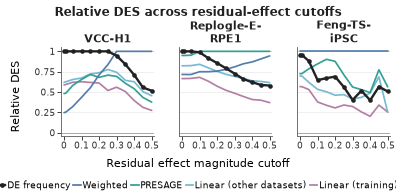

In [6]:
fig2d_rows = select_cutoff_rows(FIG2D_DATASETS, FIG2D_METHODS)

with mpl.rc_context():  # restores the notebook style after the panel
    use_style(FIG2D_RC, open_axes=True)
    save_panel(draw_fig2d(fig2d_rows), FIGURES / "relative_DES_by_residual_cutoff.pdf")

## Supplementary Fig. S3c — DES for residual-effect (conjunction) discoveries

Fig. 2b under the residual-effect truth (condition `conjunction`), same eligible perturbations and ordering rule. 75 × 133.65 mm.

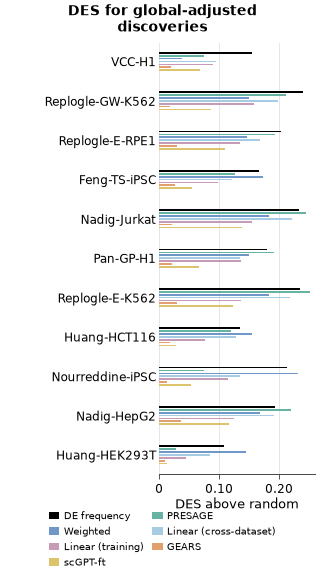

In [7]:
s3c_bars, s3c_ranking = des_above_random(des_by_perturbation, "conjunction")

# The S3c script started from the notebook style, not from the matplotlibrc defaults.
with mpl.rc_context(panel_style(BAR_RC, open_axes=True)):
    figure = draw_des_bars(s3c_bars, s3c_ranking, "DES for global-adjusted\ndiscoveries")
    save_panel(figure, FIGURES / "DES_residual_effect_discoveries.pdf")

# Fig. 2b and S3c in one table
des_table = pd.concat([
    fig2b_bars.assign(panel="Fig. 2b", discoveries="total effect"),
    s3c_bars.assign(panel="Supplementary Fig. S3c", discoveries="residual effect"),
])
des_table[["panel", "discoveries", *fig2b_bars.columns]].to_csv(DATA / "DES_above_random.csv", index=False)

## Supplementary Fig. S4 — DES and effect magnitude by response breadth

Held-out perturbations are grouped by their number of original non-target discoveries: Broad (≥ 20) and Low (1–10). Each perturbation gets one DES per method and condition (the mean over its held-out appearances with a finite DES), and the matched pool keeps the perturbations whose random, DE-frequency, Weighted and PRESAGE DES are finite in both conditions. a, b: mean DES above random (method DES minus the perturbation's random DES) under the total- and residual-effect truths; c: per-perturbation median |effect| among rejected outcomes (total effects among the original discoveries, residual effects among the conjunction discoveries), as split half-violins with a bar at each group median. Datasets are ordered by decreasing C_d = (Weighted − DE frequency)_Low − (Weighted − DE frequency)_Broad of the total-effect means. Nourreddine-iPSC is omitted, leaving 10 datasets. One 183 × 175 mm canvas.

The rcParams update below stays in effect for the rest of the notebook. The `findfont ... semibold` warnings are expected: semibold text is drawn in bold.

In [8]:
EXCLUDED_DATASETS = {"Nourreddine-GW-ipsc"}
BREADTH_GROUPS = ["Broad (≥20)", "Low (1–10)"]
S4_METHODS = [
    ("rejfreq", "DE frequency", "#1F1F1F", "o", -0.055),
    ("weighted", "Weighted", "#6F98C9", "s", 0.000),
    ("presage", "PRESAGE", "#59A99A", "^", 0.055),
]
EFFECT_CONDITIONS = [("total_original", "Total"), ("residual_conjunction", "Residual")]
MAGNITUDE_GROUPS = [("Broad (≥20)", "#6F98C9", "low"), ("Low (1–10)", "#E69662", "high")]
S4_RC = {"font.size": 6.5, "axes.linewidth": 0.55, "xtick.major.width": 0.50, "ytick.major.width": 0.50}

mpl.rcParams.update(panel_style(S4_RC, open_axes=True))


def breadth_tables(root):
    """S4 summaries from the per-dataset tables of compute_breadth_stratified_des.py."""
    conditions = ["original", "conjunction"]
    methods = [method for method, *_ in S4_METHODS]
    folders = [root / "per_dataset" / slug(dataset) for dataset in DES_DATASETS]
    scores = pd.concat([pd.read_csv(folder / "DES_by_perturbation.csv.gz") for folder in folders], ignore_index=True)
    effects = pd.concat(
        [pd.read_csv(folder / "rejected_effect_magnitude_by_perturbation.csv.gz") for folder in folders],
        ignore_index=True,
    )
    scores = (
        scores.loc[np.isfinite(scores["DES"])]
        .groupby(["dataset", "method", "condition", "perturbation"], as_index=False)["DES"]
        .mean()
    )
    pool = scores.loc[scores["method"].isin(["random"] + methods) & scores["condition"].isin(conditions)].merge(
        effects[["dataset", "perturbation", "original_rejection_count"]], on=["dataset", "perturbation"], how="left"
    )
    count = pool["original_rejection_count"]
    pool["rejection_group"] = np.select([count.ge(20), count.between(1, 10)], BREADTH_GROUPS, default=None)
    wide = (
        pool.dropna(subset=["rejection_group"])
        .pivot(index=["dataset", "rejection_group", "perturbation"], columns=["condition", "method"], values="DES")
        .reindex(columns=pd.MultiIndex.from_product([conditions, ["random"] + methods]))
        .dropna()
    )
    above = pd.concat(
        [
            (wide[(condition, method)] - wide[(condition, "random")])
            .rename("des_above_random").reset_index().assign(condition=condition, method=method)
            for condition in conditions for method in methods
        ],
        ignore_index=True,
    )
    des = above.groupby(["dataset", "condition", "rejection_group", "method"], as_index=False).agg(
        n_perturbations=("perturbation", "nunique"), mean_des_above_random=("des_above_random", "mean")
    )

    means = des.loc[des["condition"].eq("original")].pivot(
        index=["dataset", "rejection_group"], columns="method", values="mean_des_above_random"
    )
    low = means.xs("Low (1–10)", level="rejection_group")
    broad = means.xs("Broad (≥20)", level="rejection_group")
    c_d = (low["weighted"] - low["rejfreq"]) - (broad["weighted"] - broad["rejfreq"])
    order = c_d.sort_values(ascending=False, kind="mergesort").rename("C_d").reset_index()
    order["display_dataset"] = order["dataset"].map(paper_name)
    order["dataset_order"] = np.arange(len(order))

    members = wide.index.to_frame(index=False).merge(effects, on=["dataset", "perturbation"], how="left")
    magnitude = pd.concat(
        [
            members[["dataset", "perturbation", "rejection_group"]].assign(
                effect_condition=condition, median_abs_effect=members[column]
            )
            for condition, column in (
                ("total_original", "median_abs_total_effect_among_original_rejections"),
                ("residual_conjunction", "median_abs_residual_effect_among_conjunction_rejections"),
            )
        ],
        ignore_index=True,
    )
    return des, order, magnitude


if USE_REFERENCE:
    des = pd.read_csv(FROZEN_S4 / "des_breadth_summary.csv")
    order = pd.read_csv(FROZEN_S4 / "dataset_order_by_Cd.csv")
    magnitude = pd.read_csv(FROZEN_S4 / "effect_magnitude_by_perturbation_11datasets.csv.gz")
else:
    des, order, magnitude = breadth_tables(RESPONSE_BREADTH)

order = order.sort_values("dataset_order", kind="stable").reset_index(drop=True)
order = order.loc[~order["dataset"].isin(EXCLUDED_DATASETS)].copy().reset_index(drop=True)
order["dataset_order"] = np.arange(len(order))  # panel column after the exclusion, 0 = left
des = des.loc[~des["dataset"].isin(EXCLUDED_DATASETS)].copy()
magnitude = magnitude.loc[~magnitude["dataset"].isin(EXCLUDED_DATASETS)].copy()

In [9]:
def add_centered_panel_title(fig, axes, letter, title):
    y = axes[0].get_position().y1 + 0.061
    fig.text(0.010, y, letter, fontsize=9.2, fontweight="bold", va="top", ha="left")
    fig.text(0.5, y, title, fontsize=8.1, fontweight="semibold", va="top", ha="center")


def add_row_ylabel(fig, axes, label):
    bbox = axes[0].get_position()
    fig.text(
        0.018, (bbox.y0 + bbox.y1) / 2, label, fontsize=6.8, rotation=90, rotation_mode="anchor", va="center",
        ha="center",
    )


def add_breadth_xlabel(fig, axes):
    fig.text(
        0.5, axes[0].get_position().y0 - 0.058, "Original Wilcoxon discoveries per perturbation",
        fontsize=6.8, fontweight="semibold", va="center", ha="center",
    )


def draw_des_row(axes, des, order, condition):
    selected = des.loc[des["condition"].eq(condition)].copy()
    y_min, y_max = -0.025, 0.425
    x_base = np.arange(2, dtype=float)
    for column, (ax, order_row) in enumerate(zip(axes, order.itertuples(index=False))):
        part = selected.loc[selected["dataset"].eq(order_row.dataset)]
        for method, _label, color, marker, offset in S4_METHODS:
            values = (
                part.loc[part["method"].eq(method)]
                .set_index("rejection_group")
                .reindex(BREADTH_GROUPS)["mean_des_above_random"]
                .to_numpy(float)
            )
            ax.plot(
                x_base + offset, values, color=color, linewidth=1.25, marker=marker, markersize=4.2,
                markeredgewidth=0, solid_capstyle="round", zorder=4 if method == "rejfreq" else 3,
            )
        ax.axhline(0, color="#858585", linewidth=0.55, linestyle=(0, (3, 2)), zorder=1)
        ax.grid(axis="y", color="#E9E9E9", linewidth=0.45, zorder=0)
        ax.set_axisbelow(True)
        ax.set_xlim(-0.19, 1.19)
        ax.set_ylim(y_min, y_max)
        ax.set_yticks([0.0, 0.2, 0.4])
        ax.set_xticks(x_base, ["Broad\n(≥20)", "Low\n(1–10)"])
        ax.tick_params(axis="x", labelsize=5.7, length=0, pad=2.0)
        ax.tick_params(axis="y", labelsize=5.9, length=2.0, pad=1.8)
        ax.set_title(two_lines(order_row.display_dataset), fontsize=6.0, fontweight="normal", pad=3.0, linespacing=1.02)
        if column != 0:
            ax.tick_params(axis="y", labelleft=False, left=False)
            ax.spines["left"].set_visible(False)
        else:
            ax.spines["left"].set_color("#A8A8A8")
        ax.spines["bottom"].set_color("#A8A8A8")


def draw_half_violin(ax, values, position, color, side):
    values = np.asarray(values, dtype=float)
    if values.size >= 2 and float(np.ptp(values)) > np.finfo(float).eps:
        result = ax.violinplot(
            [values], positions=[position], widths=0.76, showmeans=False, showmedians=False,
            showextrema=False, points=120, bw_method="scott", side=side,
        )
        for body in result["bodies"]:
            body.set_facecolor(color)
            body.set_edgecolor(color)
            body.set_linewidth(0.45)
            body.set_alpha(0.80)
    median = float(np.median(values))
    if side == "low":
        x_interval = [position - 0.29, position - 0.035]
    else:
        x_interval = [position + 0.035, position + 0.29]
    ax.plot(x_interval, [median, median], color="#252525", linewidth=0.8, solid_capstyle="round", zorder=4)


def compact_magnitude_tick(value, _position):
    """Keep dataset-specific scales legible in narrow side-by-side panels."""
    if abs(value) < 1e-12:
        return "0"
    if abs(value) < 1:
        label = f"{value:.2f}".rstrip("0").rstrip(".")
        return label[1:] if label.startswith("0") else label
    return f"{value:.1f}".rstrip("0").rstrip(".")


def draw_magnitude_row(axes, magnitude, order):
    x_positions = np.arange(2, dtype=float)
    for ax, order_row in zip(axes, order.itertuples(index=False)):
        part = magnitude.loc[magnitude["dataset"].eq(order_row.dataset)]
        for position, (condition, _condition_label) in enumerate(EFFECT_CONDITIONS):
            for group, color, side in MAGNITUDE_GROUPS:
                values = part.loc[
                    part["effect_condition"].eq(condition) & part["rejection_group"].eq(group),
                    "median_abs_effect",
                ].to_numpy(float)
                draw_half_violin(ax, values, float(position), color, side)
        # Raw, linear, dataset-specific y axis.
        upper = float(part["median_abs_effect"].max())
        ax.set_ylim(0, upper * 1.055 if upper > 0 else 1.0)
        ax.set_xlim(-0.48, 1.48)
        ax.set_xticks(x_positions, [label for _, label in EFFECT_CONDITIONS])
        ax.tick_params(axis="x", labelsize=5.7, length=0, pad=2.2)
        plt.setp(ax.get_xticklabels(), rotation=72, ha="right", rotation_mode="anchor")
        ax.tick_params(axis="y", labelsize=5.5, length=1.8, pad=1.1)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3, min_n_ticks=2))
        ax.yaxis.set_major_formatter(FuncFormatter(compact_magnitude_tick))
        ax.grid(axis="y", color="#E9E9E9", linewidth=0.43, zorder=0)
        ax.set_axisbelow(True)
        ax.spines[["left", "bottom"]].set_color("#A8A8A8")
        ax.set_title(two_lines(order_row.display_dataset), fontsize=6.0, fontweight="normal", pad=3.0, linespacing=1.02)

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


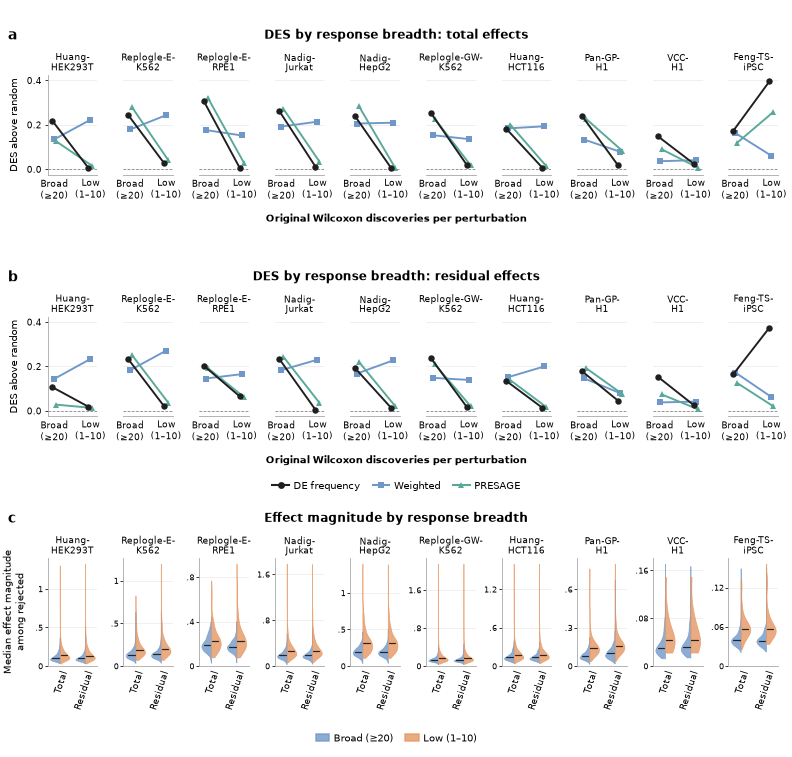

In [10]:
# 183 x 175 mm; rows a, b, c with one column per dataset. Row b shares the y axis of row a.
n_datasets = len(order)
fig = plt.figure(figsize=(7.204724, 6.889764), facecolor="white")
grid = fig.add_gridspec(
    3, n_datasets, left=0.060, right=0.982, top=0.900, bottom=0.120, wspace=0.52, hspace=1.38,
    height_ratios=[1.0, 1.0, 1.08],
)
axes_a = [fig.add_subplot(grid[0, i]) for i in range(n_datasets)]
axes_b = [fig.add_subplot(grid[1, i], sharey=axes_a[0]) for i in range(n_datasets)]
axes_c = [fig.add_subplot(grid[2, i]) for i in range(n_datasets)]

draw_des_row(axes_a, des, order, "original")
add_centered_panel_title(fig, axes_a, "a", "DES by response breadth: total effects")
add_row_ylabel(fig, axes_a, "DES above random")
add_breadth_xlabel(fig, axes_a)

draw_des_row(axes_b, des, order, "conjunction")
add_centered_panel_title(fig, axes_b, "b", "DES by response breadth: residual effects")
add_row_ylabel(fig, axes_b, "DES above random")
add_breadth_xlabel(fig, axes_b)
fig.legend(  # methods of a and b
    handles=[
        Line2D([0], [0], color=color, linewidth=1.35, marker=marker, markersize=4.5, markeredgewidth=0, label=label)
        for _method, label, color, marker, _offset in S4_METHODS
    ],
    loc="center", bbox_to_anchor=(0.5, axes_b[0].get_position().y0 - 0.092), ncol=3, fontsize=6.6,
    handlelength=1.65, handletextpad=0.45, columnspacing=1.25, borderaxespad=0,
)

draw_magnitude_row(axes_c, magnitude, order)
add_centered_panel_title(fig, axes_c, "c", "Effect magnitude by response breadth")
add_row_ylabel(fig, axes_c, "Median effect magnitude\namong rejected")
fig.legend(
    handles=[
        Patch(facecolor=color, edgecolor=color, alpha=0.80, label=group) for group, color, _side in MAGNITUDE_GROUPS
    ],
    loc="lower center", bbox_to_anchor=(0.5, 0.012), ncol=2, fontsize=6.6, handlelength=1.35,
    handletextpad=0.45, columnspacing=1.15, borderaxespad=0,
)

save_panel(fig, FIGURES / "DES_and_effect_magnitude_by_response_breadth.pdf")

In [11]:
# a, b: one row per panel, dataset column, method and breadth group.
panels = pd.DataFrame(
    {"panel": ["a", "b"], "effect": ["Total", "Residual"], "condition": ["original", "conjunction"]}
)
methods = pd.DataFrame(
    [(method, label, index) for index, (method, label, *_style) in enumerate(S4_METHODS)],
    columns=["method", "display_method", "method_order"],
)
groups = pd.DataFrame({"rejection_group": BREADTH_GROUPS, "group_order": range(len(BREADTH_GROUPS))})
des_table = (
    des[["dataset", "condition", "rejection_group", "method", "n_perturbations", "mean_des_above_random"]]
    .merge(panels, on="condition")
    .merge(order[["dataset", "display_dataset", "dataset_order"]], on="dataset")
    .merge(methods, on="method")
    .merge(groups, on="rejection_group")
    .sort_values(["panel", "dataset_order", "method_order", "group_order"])
    .rename(columns={"rejection_group": "response_breadth"})
)
des_table[[
    "panel", "effect", "condition", "dataset_order", "dataset", "display_dataset",
    "method", "display_method", "response_breadth", "n_perturbations", "mean_des_above_random",
]].to_csv(DATA / "DES_by_response_breadth.csv", index=False)

# c: one row per dataset column, effect and breadth group: the number of perturbations
# and the median and quartiles of their median |effect| (one half-violin).
effects = pd.DataFrame(
    [(condition, label, index) for index, (condition, label) in enumerate(EFFECT_CONDITIONS)],
    columns=["effect_condition", "effect", "effect_order"],
)
groups = pd.DataFrame(
    [(group, index) for index, (group, _color, _side) in enumerate(MAGNITUDE_GROUPS)],
    columns=["rejection_group", "group_order"],
)
magnitude_table = (
    magnitude.groupby(["dataset", "effect_condition", "rejection_group"], as_index=False)["median_abs_effect"]
    .agg(
        n_perturbations="size",
        median_abs_effect_median="median",
        median_abs_effect_q25=lambda values: values.quantile(0.25),
        median_abs_effect_q75=lambda values: values.quantile(0.75),
    )
    .merge(order[["dataset", "display_dataset", "dataset_order"]], on="dataset")
    .merge(effects, on="effect_condition")
    .merge(groups, on="rejection_group")
    .sort_values(["dataset_order", "effect_order", "group_order"])
    .rename(columns={"rejection_group": "response_breadth"})
)
magnitude_table[[
    "dataset_order", "dataset", "display_dataset", "effect", "effect_condition", "response_breadth",
    "n_perturbations", "median_abs_effect_median", "median_abs_effect_q25", "median_abs_effect_q75",
]].to_csv(DATA / "effect_magnitude_by_response_breadth_summary.csv", index=False)

## Supplementary Fig. S5b — relative DES across residual-effect cutoffs, seven more screens

Fig. 2d for seven more screens and seven methods; Nourreddine-iPSC and Feng-GW-iPSC are excluded. 183 × 52 mm.

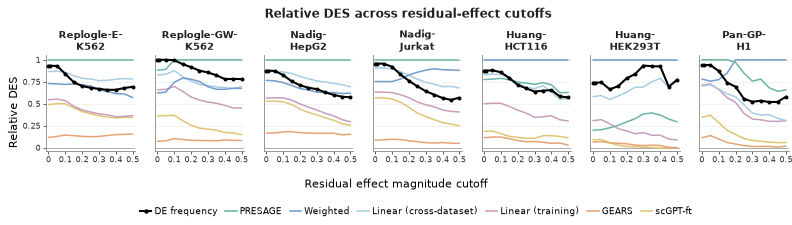

In [12]:
S5B_DATASETS = [
    "Replogle-E-k562", "Replogle-GW-k562", "Nadig-HEPG2", "Nadig-JURKAT", "Huang-HCT116", "Huang-HEK293T",
    "Pan-GW-hESC",
]
# Order and colors as in Fig. 2b; DE frequency thicker and with markers.
S5B_METHODS = [
    (key, label, color, 1.35 if key == "rejfreq" else 1.00, "o" if key == "rejfreq" else None)
    for key, label, color in BAR_METHODS
]
S5B_RC = {
    "font.size": 6.2, "axes.linewidth": 0.55, "xtick.major.width": 0.50, "ytick.major.width": 0.50,
    "xtick.major.size": 2.2, "ytick.major.size": 2.2,
}


def draw_s5b(selected):
    figure, axes = plt.subplots(1, 7, figsize=(183.0 * MM, 52.0 * MM), sharex=True, sharey=True, squeeze=False)
    figure.subplots_adjust(left=0.058, right=0.995, bottom=0.330, top=0.755, wspace=0.22)
    for index, (axis, dataset) in enumerate(zip(axes.flat, S5B_DATASETS)):
        panel = selected.loc[selected["dataset"].eq(dataset)]
        # Reverse draw order keeps the black DE-frequency trajectory visible.
        for method, _label, color, linewidth, marker in reversed(S5B_METHODS):
            line = panel.loc[panel["method"].eq(method)].sort_values("threshold")
            axis.plot(
                line["threshold"].to_numpy(float), line["normalized_DES"].to_numpy(float), color=color,
                linewidth=linewidth, marker=marker, markersize=2.6 if marker else 0, markeredgewidth=0,
                alpha=1.0 if method == "rejfreq" else 0.96, solid_capstyle="round",
                zorder=4 if method == "rejfreq" else 3,
            )

        axis.set_xlim(-0.015, 0.515)
        axis.set_ylim(-0.035, 1.055)
        axis.set_xticks(np.arange(0.0, 0.51, 0.1), ["0", "0.1", "0.2", "0.3", "0.4", "0.5"])
        axis.set_yticks([0, 0.25, 0.5, 0.75, 1], ["0", "0.25", "0.5", "0.75", "1"])
        axis.tick_params(axis="both", labelsize=5.3, pad=1.3, colors="#333333")
        axis.tick_params(axis="y", labelleft=index == 0, left=index == 0)
        axis.set_title(two_lines(paper_name(dataset)), fontsize=6.4, fontweight="bold", pad=3.4, color="#222222")
        axis.axhline(0, color="#A2A2A2", linewidth=0.55, zorder=1)
        axis.axhline(1, color="#D0D0D0", linewidth=0.45, linestyle=(0, (3, 2)), zorder=1)
        axis.grid(axis="y", color="#EAEAEA", linewidth=0.40, zorder=0)
        axis.grid(axis="x", visible=False)
        axis.set_axisbelow(True)
        axis.spines[["left", "bottom"]].set_color("#888888")

    figure.suptitle(
        "Relative DES across residual-effect cutoffs", x=0.515, y=0.965, fontsize=8.0, fontweight="bold",
        color="#202020",
    )
    figure.supxlabel("Residual effect magnitude cutoff", fontsize=7.0, y=0.155)
    figure.supylabel("Relative DES", fontsize=7.0, x=0.010)
    handles = [
        Line2D(
            [0], [0], color=color, linewidth=linewidth, marker=marker, markersize=2.9 if marker else 0,
            markeredgewidth=0, label=label,
        )
        for _method, label, color, linewidth, marker in S5B_METHODS
    ]
    figure.legend(
        handles=handles, loc="lower center", bbox_to_anchor=(0.525, 0.022), ncol=7, fontsize=6.0,
        handlelength=1.25, handletextpad=0.35, columnspacing=0.85, borderaxespad=0,
    )
    return figure


s5b_rows = select_cutoff_rows(S5B_DATASETS, S5B_METHODS)

with mpl.rc_context(panel_style(S5B_RC, open_axes=True)):
    save_panel(draw_s5b(s5b_rows), FIGURES / "relative_DES_by_residual_cutoff_other_datasets.pdf")

# Fig. 2d and S5b in one table
cutoff_table = pd.concat([
    fig2d_rows.assign(panel="Fig. 2d"),
    s5b_rows.assign(panel="Supplementary Fig. S5b"),
]).astype({"dataset": str, "method": str})
cutoff_table[["panel", *fig2d_rows.columns]].to_csv(DATA / "relative_DES_by_residual_cutoff.csv", index=False)